In [1]:
#Logistic_Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report,
    confusion_matrix
)

# Load dataset
path = r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 8\diabetes.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()
df.describe()
print(df.isnull().sum())

print(df["Outcome"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0


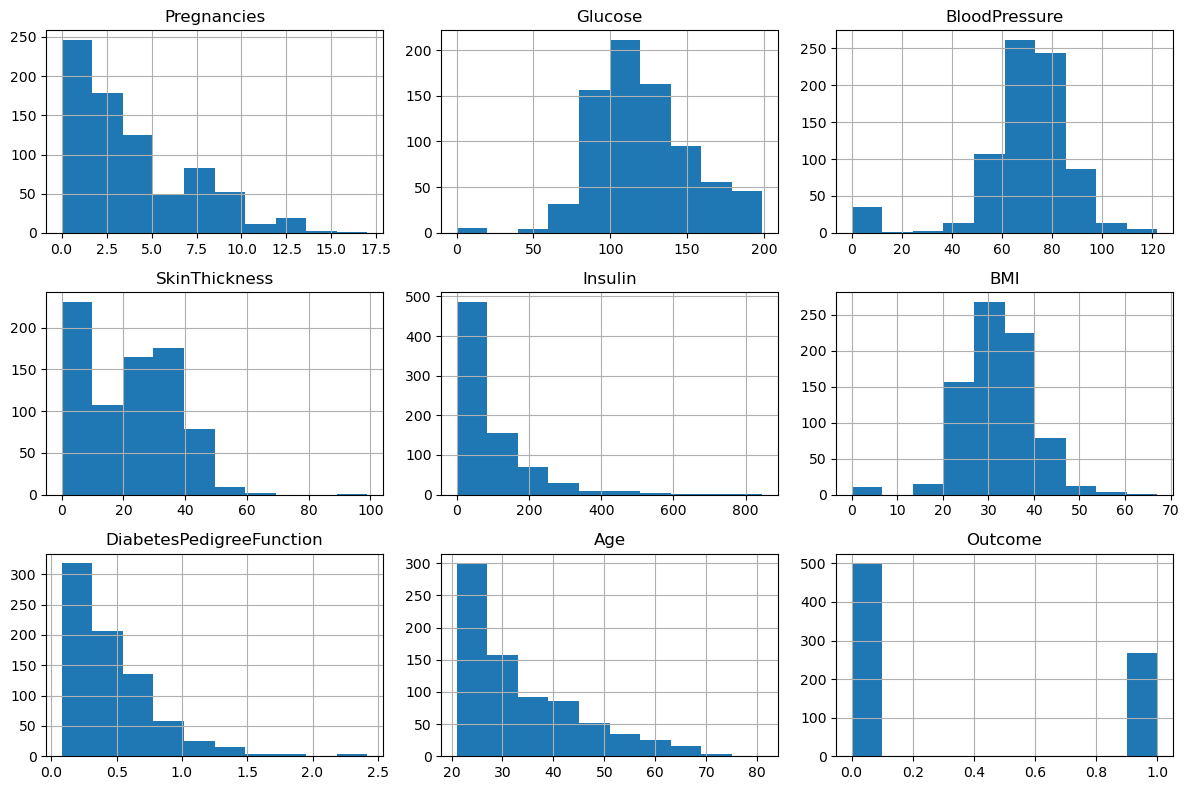

In [6]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

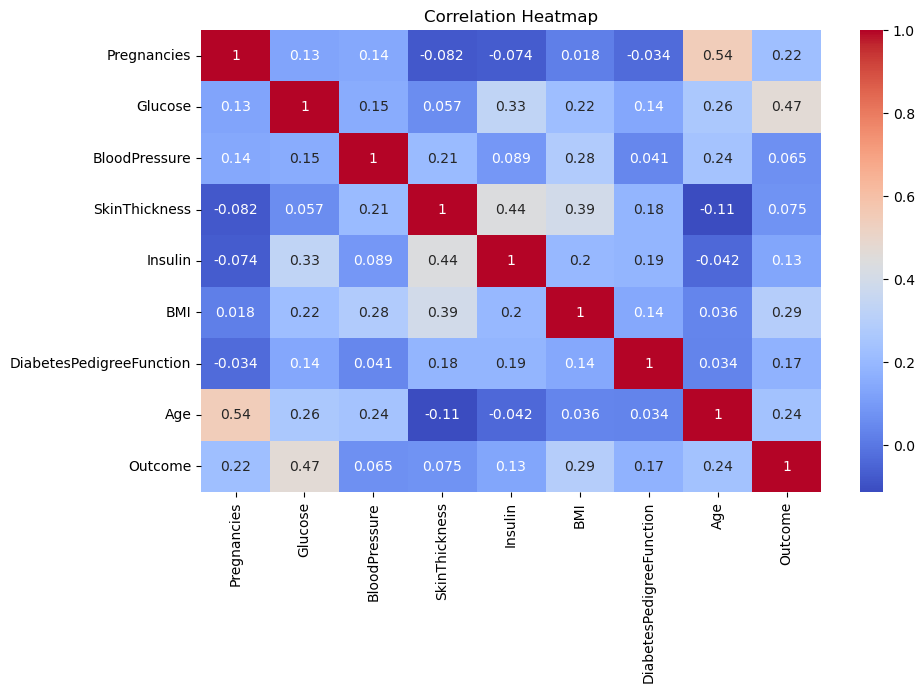

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

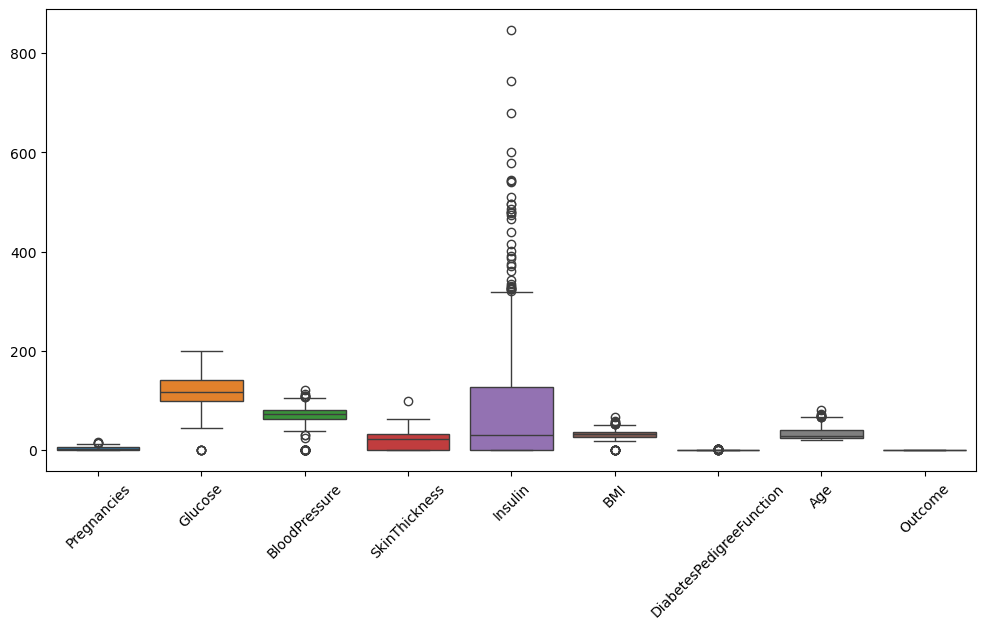

In [8]:
#EDA Observation
#Glucose has a strong relationship with Outcome.
#BMI, Age and Pregnancies also show some relationship with diabetes.
#Some variables such as Insulin and SkinThickness contain zero values,
#which may represent missing measurements in the original data.

In [9]:
# Replace medically impossible zero values with NaN
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Fill missing values with median
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

# Separate X and y
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Create and train model
model = LogisticRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454
ROC-AUC  : 0.812962962962963


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



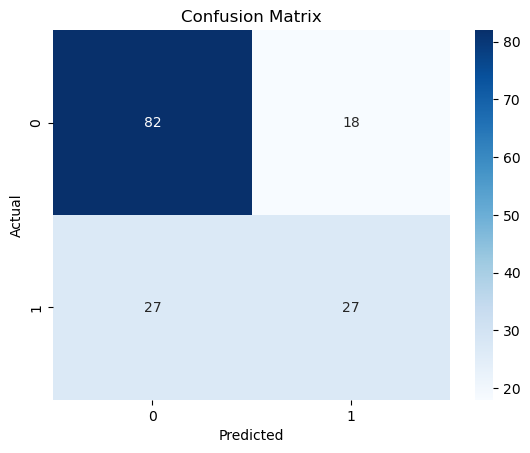

In [13]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

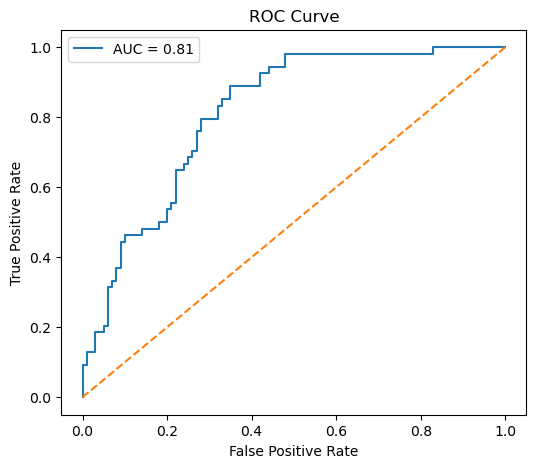

In [14]:
#ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
# Feature coefficients
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef["Odds_Ratio"] = np.exp(coef["Coefficient"])

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient,Odds_Ratio
1,Glucose,1.182511,3.262558
5,BMI,0.688735,1.991194
0,Pregnancies,0.377502,1.458637
6,DiabetesPedigreeFunction,0.233386,1.262869
7,Age,0.147798,1.159279
3,SkinThickness,0.028225,1.028627
2,BloodPressure,-0.044066,0.956891
4,Insulin,-0.066157,0.935983


In [16]:
Positive coefficient → increases the probability of diabetes.
Negative coefficient → decreases the probability of diabetes.

A larger absolute coefficient indicates a stronger influence
on the log-odds of the target, although interpretation should
also consider scaling and correlation between features.

Odds Ratio > 1 → increased odds of diabetes.
Odds Ratio < 1 → decreased odds of diabetes.

SyntaxError: invalid character '→' (U+2192) (4073971580.py, line 1)

In [17]:
# 5-fold cross-validation
cv_scores = cross_val_score(
    LogisticRegression(),
    StandardScaler().fit_transform(X),
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

CV Scores: [0.75974026 0.74675325 0.78571429 0.79738562 0.77124183]
Average CV Accuracy: 0.7721670486376369


In [18]:
#Q1. Precision vs Recall
Precision = TP / (TP + FP)


Precision answers:
"Of all people predicted as diabetic, how many are actually diabetic?"


Recall = TP / (TP + FN)


Recall answers:
"Of all actually diabetic people, how many did the model correctly identify?"


For medical diagnosis, recall can be particularly important because
missing an actual diabetic patient (False Negative) can be costly.

SyntaxError: invalid syntax (2410054848.py, line 5)

In [19]:
#Q2. What is Cross-Validation?
Cross-validation is a technique used to evaluate how well a model
generalizes to unseen data.


In 5-fold cross-validation, the dataset is divided into 5 parts.
The model trains on 4 parts and validates on the remaining part.
This process is repeated 5 times.


It provides a more reliable performance estimate and helps identify
overfitting.

SyntaxError: invalid syntax (749100604.py, line 2)